In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random
from utilityFunctions import (
    load_csv_to_matrix_batch,
    compute_color_similarity_distance_batch,
    show_heatmaps
)
import ot
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [19]:
def make_rotational_candidates(n: int):
    """
    Build 24 candidates for an n x n OT plan (n=12 expected):
      - 12 cyclic row shifts of the identity (down by s = 0..n-1)
      - 12 rotation-90° clockwise of each shifted matrix
    Returns:
      candidates: list[np.ndarray] of shape (n, n)
      labels:     list[str] same length as candidates
    """
    eye = np.eye(n)
    candidates, labels = [], []

    for s in range(n):
        # cyclic row shift (down) by s
        P = np.roll(eye, shift=s, axis=0)
        candidates.append(P)
        labels.append(f"shift_{s}")

        # 90° clockwise rotation of the shift
        # np.rot90(..., k=-1) rotates 90° clockwise
        P_rot = np.rot90(P, k=-1)
        candidates.append(P_rot)
        labels.append(f"shift_{s}_rot90")

    return candidates, labels


def candidate_matching_scores(OT: np.ndarray,
                              candidates: list[np.ndarray],
                              method: str = "fro_norm",
                              threshold: float | None = None):
    """
    Compute a score for each candidate vs the OT plan.
    Methods:
      - "fro_norm": <OT, P> / (||OT||_F * ||P||_F)  in [0,1]
      - "mass_fraction": sum(OT * P) / sum(OT)      in [0,1]
      - "threshold_hits": fraction of positions where both OT>=threshold and P==1
                          (requires 'threshold' argument)
    Returns: scores (list[float])
    """
    OT = np.asarray(OT, dtype=float)
    scores = []

    if method == "fro_norm":
        ot_norm = np.linalg.norm(OT, ord="fro")
        for P in candidates:
            denom = ot_norm * np.linalg.norm(P, ord="fro")
            # safe guard if denom == 0
            score = 0.0 if denom == 0 else float(np.sum(OT * P) / denom)
            scores.append(score)

    elif method == "mass_fraction":
        ot_sum = float(OT.sum())
        for P in candidates:
            score = 0.0 if ot_sum == 0 else float(np.sum(OT * P) / ot_sum)
            scores.append(score)

    elif method == "threshold_hits":
        if threshold is None:
            raise ValueError("threshold_hits method requires a 'threshold' value.")
        mask = (OT >= threshold)
        denom = mask.sum()
        for P in candidates:
            # count how many 'active' OT entries land on candidate ones
            hits = np.logical_and(mask, (P == 1)).sum()
            score = 0.0 if denom == 0 else float(hits / denom)
            scores.append(score)
    else:
        raise ValueError(f"Unknown method '{method}'. Choose from 'fro_norm', 'mass_fraction', 'threshold_hits'.")

    return scores


def plot_candidate_scores(scores, labels, title="Rotational Candidate Matching Rates"):
    """
    Simple line plot of 24 candidate scores.
    """
    x = np.arange(len(scores))
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores, marker='o')
    plt.xticks(x, labels, rotation=60, ha='right', fontsize=8)
    plt.ylabel("Matching Rate (score)")
    plt.xlabel("Candidate")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
def GWD_and_plot(matrix1, matrix2, epsilons,
                 rotinv_method: str = "fro_norm",
                 rotinv_threshold: float | None = None,
                 plot_candidates: bool = True):

    def comp_matching_rate(OT_plan, k, order="maximum"):
        diagonal = np.diag(OT_plan)
        if order == "maximum":
            topk_values = np.partition(OT_plan, -k)[:, -k:]
        elif order == "minimum":
            topk_values = np.partition(OT_plan, k - 1)[:, :k]
        count = np.sum([diagonal[i] in topk_values[i] for i in range(OT_plan.shape[0])])
        return count / OT_plan.shape[0] * 100.0
    
    print("Computing Gromov-Wasserstein distances and optimal transport plans...")

    OT_plans, gwds, matching_rates, valid_epsilons = [], [], [], []

    for epsilon in epsilons:
        OT, gw_log = ot.gromov.entropic_gromov_wasserstein(
            C1=matrix1, C2=matrix2, epsilon=epsilon, loss_fun="square_loss", log=True
        )
        if not OT.any():
            print(f"Skipping epsilon={epsilon} because it results in a zero transportation matrix.")
            continue
        gwd = gw_log['gw_dist']
        mr = comp_matching_rate(OT, k=1)

        OT_plans.append(OT)
        gwds.append(gwd)
        matching_rates.append(mr)
        valid_epsilons.append(epsilon)

        print(f"Epsilon: {epsilon}, GWD: {gwd}, Matching Rate: {mr}")

    if not gwds:
        raise ValueError("No valid epsilon values resulted in a non-zero transportation matrix.")

    # Identify best epsilon
    min_gwd = min(gwds)
    best_idx = int(np.argmin(gwds))
    best_eps = valid_epsilons[best_idx]
    OT_plan = OT_plans[best_idx]
    matching_rate = matching_rates[best_idx]

    print(f"Best epsilon: {best_eps}, Minimum GWD: {min_gwd:.3f}")

    # Plot GWD vs epsilon with color by (standard) matching rate
    plt.figure()
    sc = plt.scatter(valid_epsilons, gwds, c=matching_rates, cmap="viridis")
    plt.xlabel("epsilon")
    plt.ylabel("GWD")
    plt.xscale("log")
    plt.grid(True, which="both")
    cbar = plt.colorbar(sc)
    cbar.set_label(label="Matching Rate (%)")
    plt.scatter([best_eps], [min_gwd], color="red", marker="o", label=f"Best ε={best_eps}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # OT plan heatmap
    show_heatmaps(
        0, 0.1,
        matrices=[OT_plan],
        titles=[f'Optimal transportation plan \n GWD={min_gwd:.3f} \n Best ε={best_eps} \n Matching rate: {matching_rate:.1f}%'],
        nrows=1, ncols=1, cbar_label=None, color_labels=None, cmap_name='viridis'
    )

    # ---- Rotation-invariant matching rate & plot ----
    n = OT_plan.shape[0]
    candidates, labels = make_rotational_candidates(n)
    cand_scores = candidate_matching_scores(OT_plan, candidates,
                                            method=rotinv_method,
                                            threshold=rotinv_threshold)
    rotinv_max_score = float(np.max(cand_scores))
    rotinv_best_label = labels[int(np.argmax(cand_scores))]
    print(f"RotInv best candidate: {rotinv_best_label}, score={rotinv_max_score:.3f}")

    if plot_candidates:
        plot_candidate_scores(
            cand_scores,
            labels,
            title="Rotational Candidate Matching Rates (vs. OT plan at best ε)"
        )

    # Return everything your code already expects, plus the rotation-invariant max
    return OT_plan, gwds, matching_rates, min_gwd, matching_rate, candidates, labels, cand_scores, rotinv_best_label, rotinv_max_score


Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv
Group1 (9): [13, 0, 1, 6, 3, 4, 14, 17, 11]
Group2 (10): [9, 2, 12, 15, 10, 16, 8, 7, 5, 18]


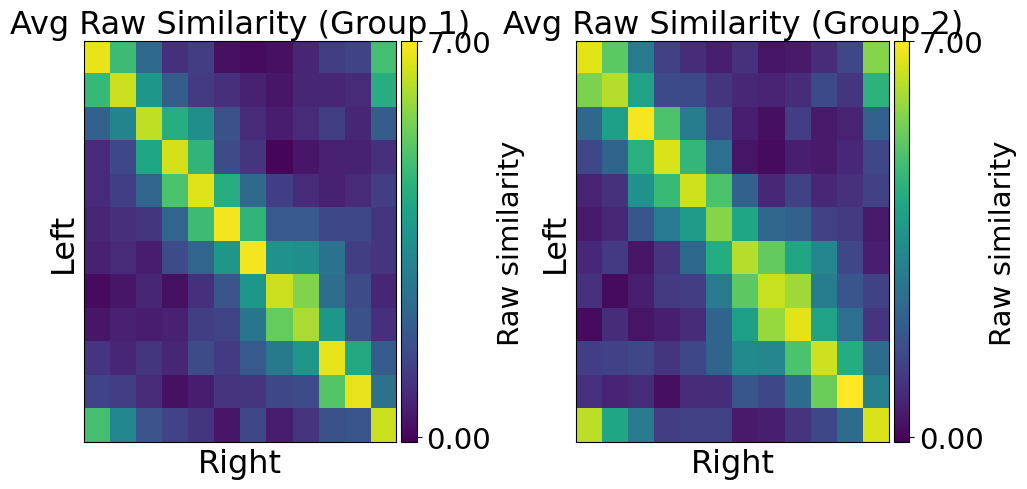

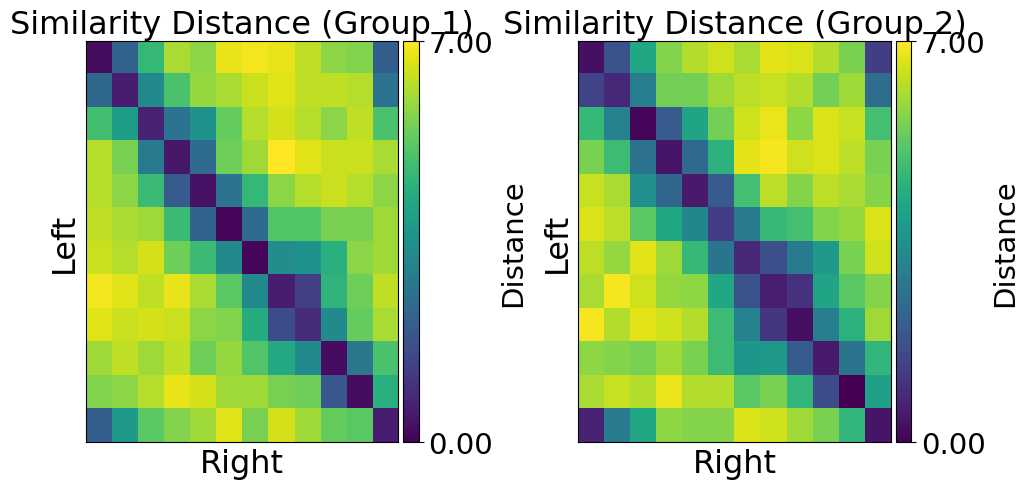

Computing Gromov-Wasserstein distances and optimal transport plans...
Epsilon: 0.04000000000000001, GWD: 2.6593396856796065, Matching Rate: 25.0


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.05289504508500041, GWD: 3.0111951726493675, Matching Rate: 41.66666666666667
Epsilon: 0.0699471448636056, GWD: 2.224473435879468, Matching Rate: 33.33333333333333
Epsilon: 0.0924964345281868, GWD: 2.225736779351193, Matching Rate: 33.33333333333333
Epsilon: 0.12231507686425572, GWD: 1.9337633550789555, Matching Rate: 25.0
Epsilon: 0.16174653763275235, GWD: 1.9429207663990948, Matching Rate: 25.0
Epsilon: 0.21388976001067866, GWD: 1.8204876938445491, Matching Rate: 8.333333333333332
Epsilon: 0.28284271247461906, GWD: 0.9690918578265904, Matching Rate: 0.0
Epsilon: 0.3740244507077194, GWD: 0.9862773051323848, Matching Rate: 0.0
Epsilon: 0.49460100457693307, GWD: 1.0204836702183255, Matching Rate: 0.0
Epsilon: 0.6540485609045841, GWD: 1.0846369653991959, Matching Rate: 0.0
Epsilon: 0.86489820292069, GWD: 1.1987316691354923, Matching Rate: 0.0
Epsilon: 1.1437207359356425, GWD: 1.3848183360046258, Matching Rate: 0.0
Epsilon: 1.5124289972991412, GWD: 2.0188391137854547, Matching R

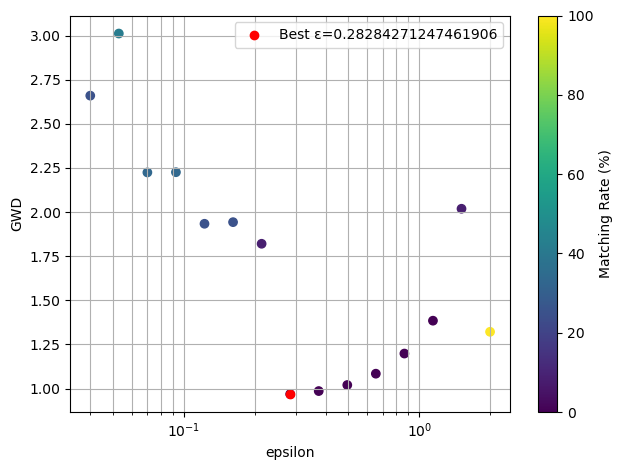

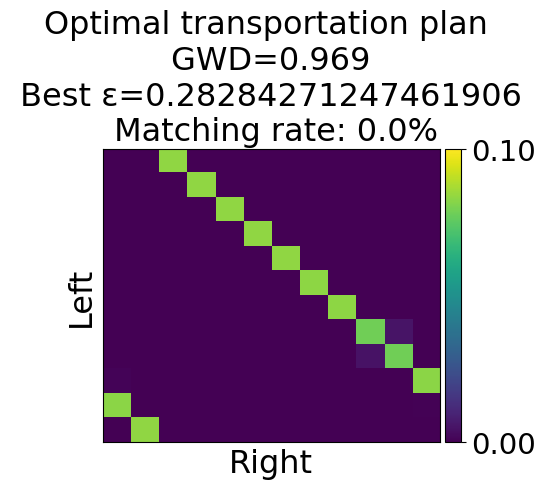

RotInv best candidate: shift_10, score=0.999


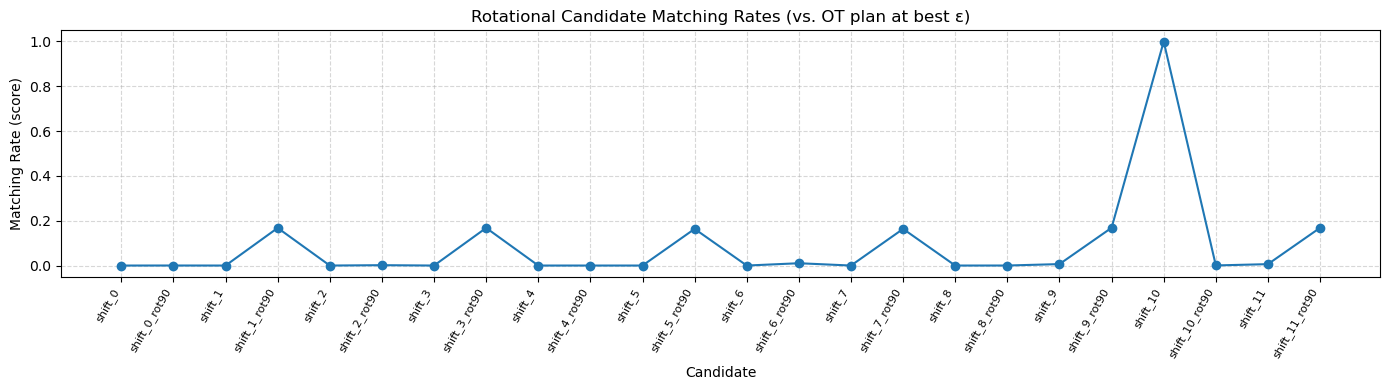

In [34]:
# -----------------------
# Config you already use
# -----------------------
folder_path = 'raw_data/202411_data'
response_type = 'similarity'
unique_colours = np.array(['#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a',
                           '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'])
colour_index = {c: i for i, c in enumerate(unique_colours)}
matrix_size = len(unique_colours)

# Epsilons for GWOT
n_eps = 15
eps_range = [0.04, 2]
epsilons = np.logspace(np.log10(eps_range[0]), np.log10(eps_range[1]), n_eps)

# -----------------------
# Load raw similarity matrices (list length = 19)
# Each element is a 12x12 matrix of raw similarity ratings
# -----------------------
subject_matrices_similarity_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

# -----------------------
# Reproducible split: 9 vs 10
# -----------------------
rng_seed = 33            # change or remove for different random splits
random.seed(rng_seed)

n_subjects = len(subject_matrices_similarity_raw)  # expected 19
idx = list(range(n_subjects))
random.shuffle(idx)
group1_idx = idx[:9]
group2_idx = idx[9:]

print(f"Group1 (9): {group1_idx}")
print(f"Group2 (10): {group2_idx}")

# -----------------------
# Average raw similarity matrices within each group
# (average first, then convert to distance — recommended)
# -----------------------
g1_raw = np.mean([subject_matrices_similarity_raw[i] for i in group1_idx], axis=0)
g2_raw = np.mean([subject_matrices_similarity_raw[i] for i in group2_idx], axis=0)

# Visualize the raw averages (optional)
show_heatmaps(
    vmin_val=7,
    vmax_val=0,
    matrices=[g1_raw, g2_raw],
    titles=["Avg Raw Similarity (Group 1)", "Avg Raw Similarity (Group 2)"],
    nrows=1, ncols=2, cmap_name="viridis", cbar_label="Raw similarity", color_labels=None
)

# -----------------------
# Convert the two averaged raw matrices into similarity-distance matrices
# (utility returns a list; index [0] gets the matrix)
# -----------------------
subject_matrices_similarity_distance = compute_color_similarity_distance_batch(subject_matrices_similarity_raw)
g1_dist = np.mean([subject_matrices_similarity_distance[i] for i in group1_idx], axis=0)
g2_dist = np.mean([subject_matrices_similarity_distance[i] for i in group2_idx], axis=0)

# Visualize distances (what GWOT will see)
show_heatmaps(
    vmin_val=0, vmax_val=7,
    matrices=[g1_dist, g2_dist],
    titles=["Similarity Distance (Group 1)", "Similarity Distance (Group 2)"],
    nrows=1, ncols=2, cmap_name="viridis", cbar_label="Distance", color_labels=None
)

# -----------------------
# Run GWOT on the two distance matrices
# -----------------------
OT_plan, gwds, matching_rates, min_gwd, matching_rate, candidates, labels, cand_scores, rotinv_best_label, rotinv_max_score = GWD_and_plot(
    g1_dist, g2_dist, epsilons
)

# You’ll see the scatter (GWD vs epsilon), the chosen best epsilon,
# and the OT plan heatmap printed/plot by GWD_and_plot.

In [35]:
def generate_permuted_ot_plans(OT_plan: np.ndarray):
    """
    From a base OT plan (n x n), generate 24 permuted versions:
      - 12 cyclic column shifts (shift target labels by s = 0..n-1)
      - 12 90° clockwise rotations of each shifted version
    Returns:
      plans:  list of (n x n) arrays
      labels: list of str labels for each plan
    """
    n = OT_plan.shape[0]
    assert OT_plan.shape[0] == OT_plan.shape[1], "OT_plan must be square."

    plans, labels = [], []
    for s in range(n):
        # Cyclic shift of target labels: shift columns (axis=1)
        shifted = np.roll(OT_plan, shift=s, axis=1)
        plans.append(shifted)
        labels.append(f"shift_{s}")

        # 90° clockwise rotation of the shifted plan
        rotated = np.rot90(shifted, k=-1)  # clockwise
        plans.append(rotated)
        labels.append(f"shift_{s}_rot90")

    return plans, labels


def plot_permuted_ot_plans(OT_plan: np.ndarray,
                           candidate_scores: list[float] | None = None,
                           ncols: int = 6,
                           cmap: str = "viridis"):
    """
    Plot all 24 permuted OT plans in one figure (4x6 by default) with a shared colorbar.
    If candidate_scores is provided (length 24), it will be shown in each panel title.
    """
    plans, labels = generate_permuted_ot_plans(OT_plan)
    n_to_plot = len(plans)  # should be 24 for n=12
    nrows = int(np.ceil(n_to_plot / ncols))

    # Determine shared color scale across all panels
    vmin = min(p.min() for p in plans)
    vmax = max(p.max() for p in plans)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows))
    axes = axes.flatten()

    im_last = None
    for i, (ax, P, lab) in enumerate(zip(axes, plans, labels)):
        if i >= n_to_plot:
            ax.axis("off")
            continue
        im_last = ax.imshow(P, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
        title = lab
        if candidate_scores is not None and i < len(candidate_scores):
            title = f"{lab}\nscore={candidate_scores[i]:.3f}"
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

    # Hide any extra axes if grid > 24
    for ax in axes[n_to_plot:]:
        ax.axis("off")

    # Add one shared colorbar on the right (no overlap)
    fig.subplots_adjust(right=0.90, wspace=0.35, hspace=0.6)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im_last, cax=cbar_ax, label="Transport Mass")

    plt.suptitle("All Permuted OT Plans (12 shifts + 12 rotated)", y=0.98, fontsize=14)
    plt.show()

    return plans, labels

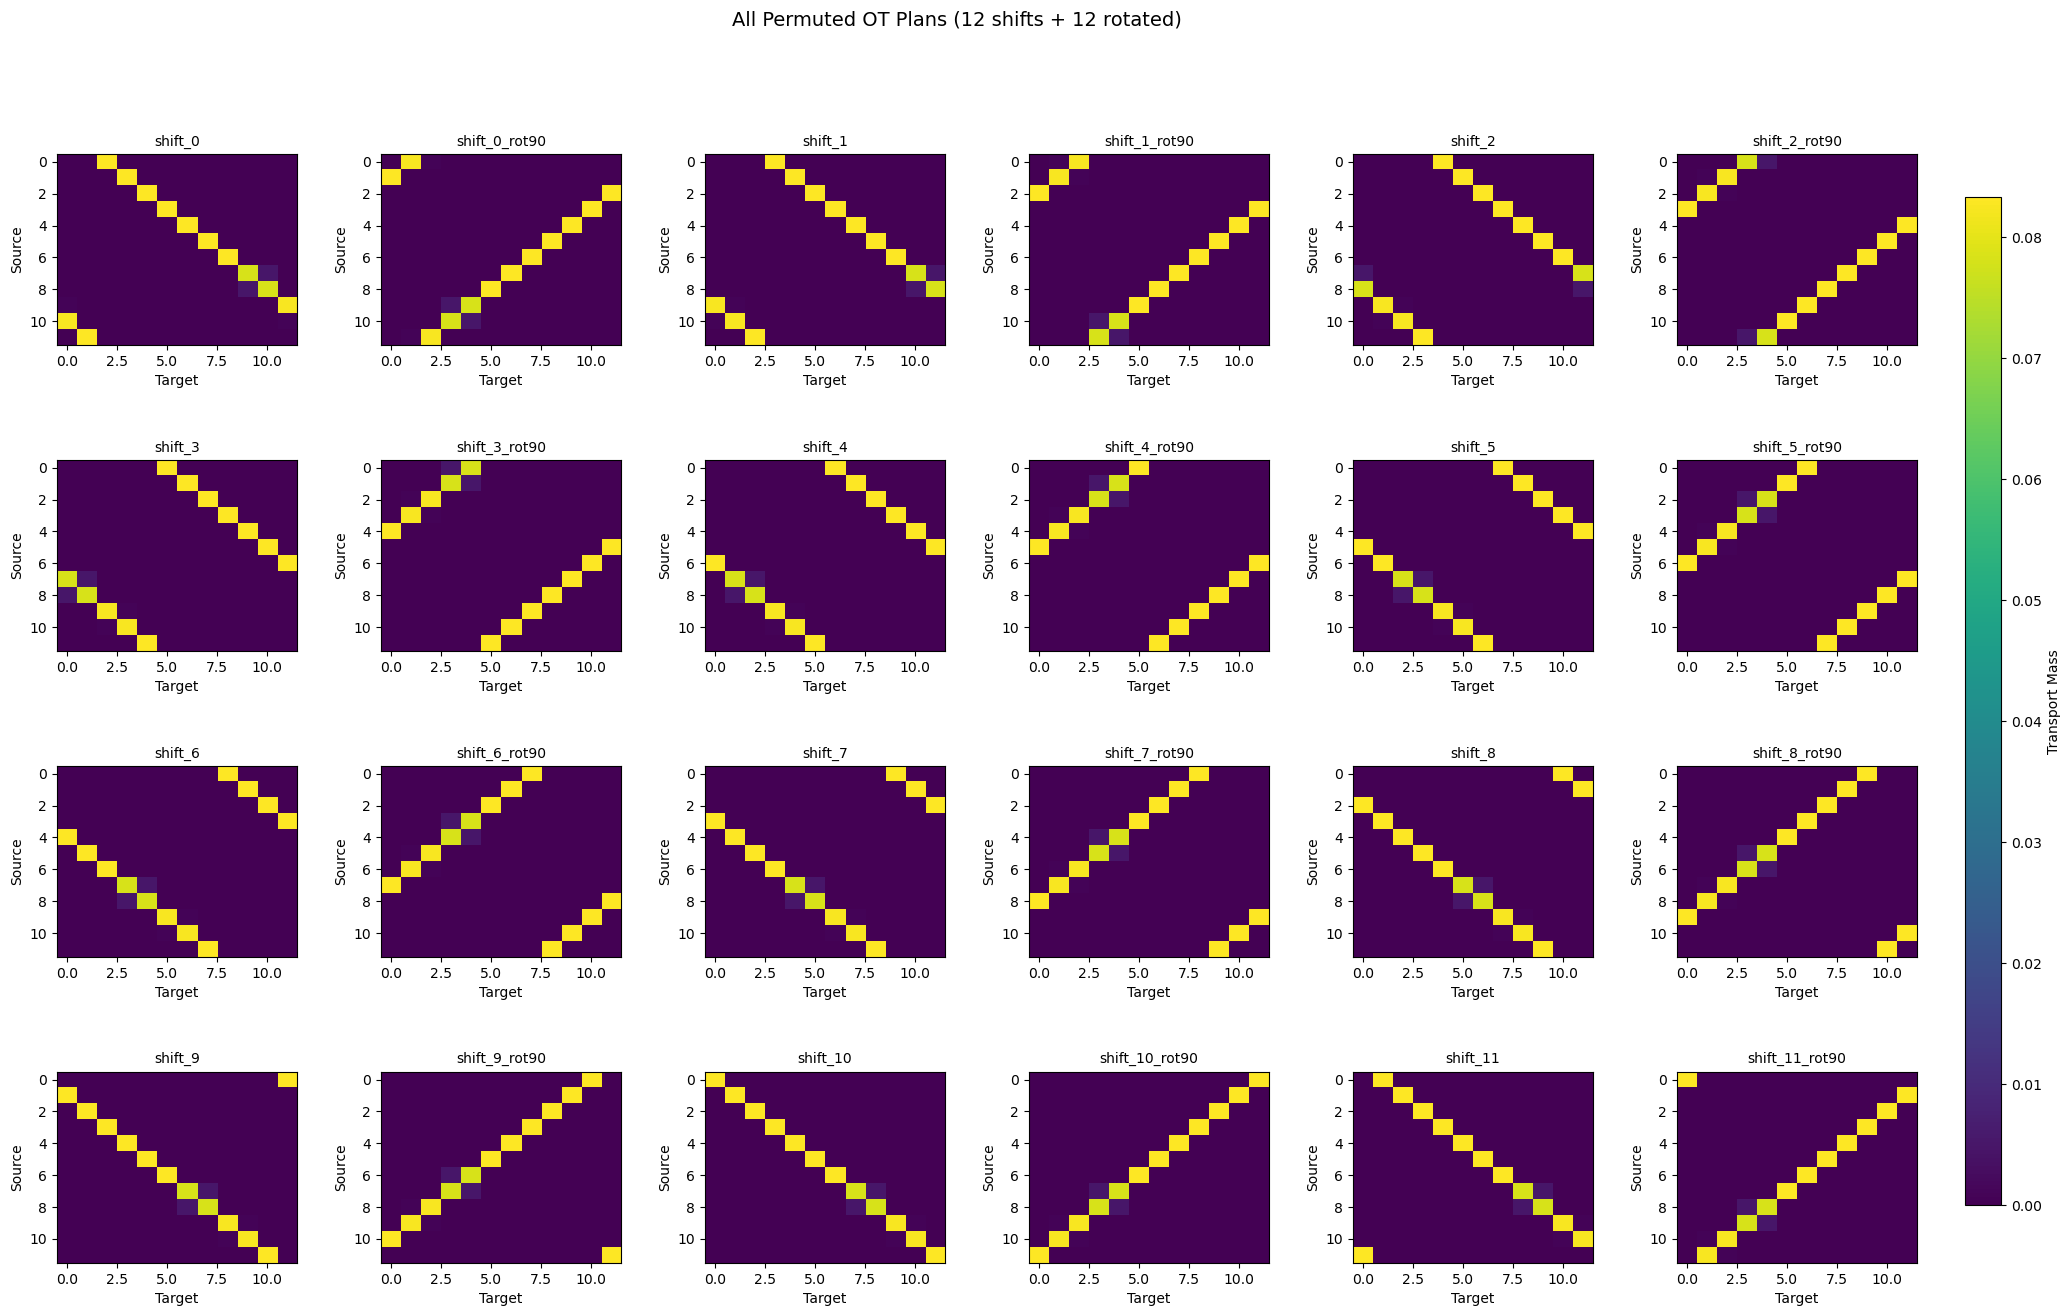

In [36]:
# If you already computed candidate scores elsewhere (e.g., rotation-invariant scoring),
# pass them in to annotate each panel. Otherwise, omit the argument.
_ = plot_permuted_ot_plans(OT_plan)  # or plot_permuted_ot_plans(OT_plan, candidate_scores=scores)
